CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [ ]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 38.7MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.22MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 9.29MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.86MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [ ]:
# TODO
model = myCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 결과 저장을 위한 리스트 초기화
train_losses = []
test_losses = []
test_accuracies = []

모델 학습 ✅

In [ ]:
# TODO
def train(epoch):
    model.train()
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    return train_loss

모델 평가 ✅

In [ ]:
# TODO
def test():
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    accuracy = 100. * correct / len(test_loader.dataset)
    test_accuracies.append(accuracy)
    return test_loss, accuracy

10회 반복 시행 ✅

In [ ]:
# TODO
n_epochs = 10

for epoch in range(1, n_epochs + 1):
    train_loss = train(epoch)
    test_loss, accuracy = test()
    print(f'에포크: {epoch}')
    print(f'학습 손실: {train_loss:.4f}')
    print(f'테스트 손실: {test_loss:.4f}')
    print(f'정확도: {accuracy:.2f}%\n')

에포크: 1
학습 손실: 0.1300
테스트 손실: 0.0391
정확도: 98.69%

에포크: 2
학습 손실: 0.0388
테스트 손실: 0.0277
정확도: 99.11%

에포크: 3
학습 손실: 0.0260
테스트 손실: 0.0333
정확도: 98.95%

에포크: 4
학습 손실: 0.0206
테스트 손실: 0.0265
정확도: 99.30%

에포크: 5
학습 손실: 0.0168
테스트 손실: 0.0281
정확도: 99.21%

에포크: 6
학습 손실: 0.0139
테스트 손실: 0.0295
정확도: 99.15%

에포크: 7
학습 손실: 0.0111
테스트 손실: 0.0394
정확도: 98.99%

에포크: 8
학습 손실: 0.0113
테스트 손실: 0.0326
정확도: 99.04%

에포크: 9
학습 손실: 0.0100
테스트 손실: 0.0335
정확도: 99.28%

에포크: 10
학습 손실: 0.0093
테스트 손실: 0.0345
정확도: 99.08%



결과 시각화

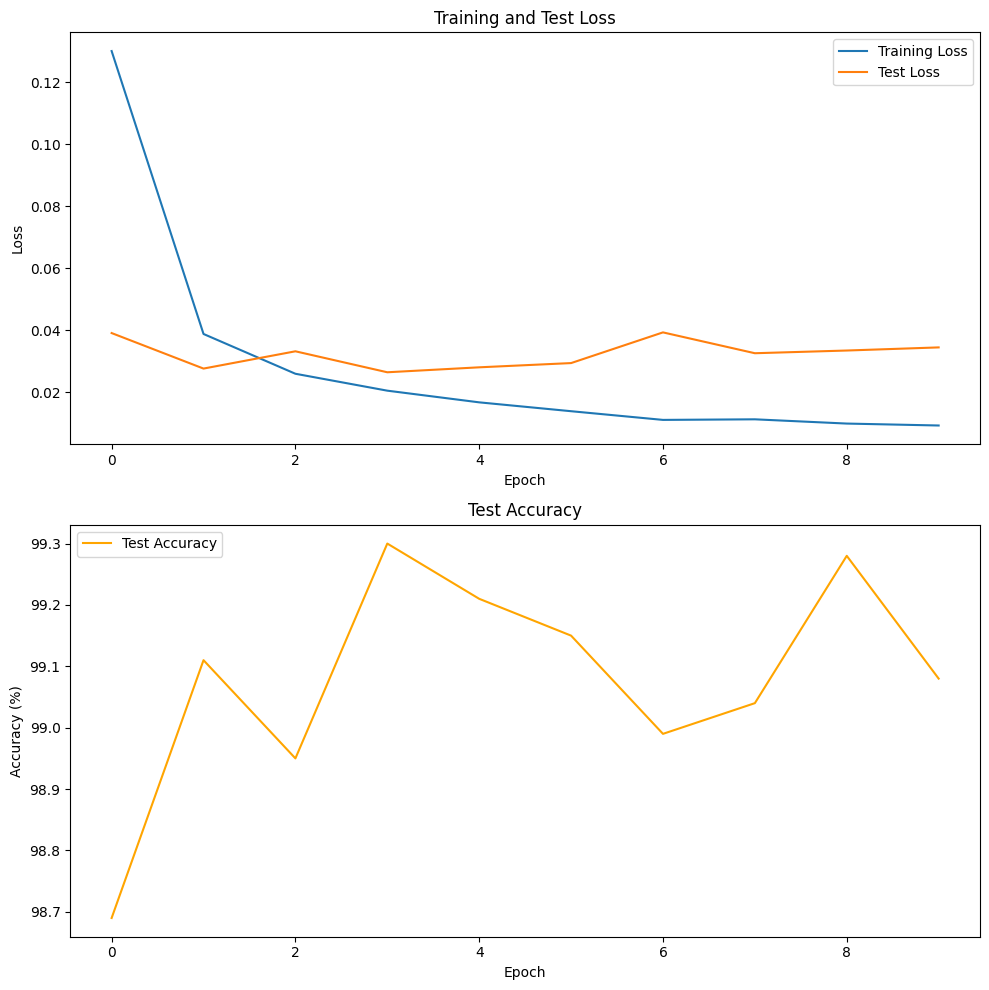

In [ ]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()